<a href="https://colab.research.google.com/github/aayushchourasia123/Machine-Learning/blob/main/handling%20missing%20data-1/CCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/data_science_job.csv')
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [4]:
df.isnull().mean()*100    # % of data missing in each column

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [5]:
df.shape

(19158, 13)

In [7]:
cols = []
for val in df.columns:
  if (df[val].isnull().mean()*100 < 5) & (df[val].isnull().mean()*100 > 0):
    cols.append(val)

cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
97,0.579,Full time course,Graduate,2.0,34.0
10506,0.923,no_enrollment,Graduate,19.0,30.0
8707,0.920,Full time course,Graduate,3.0,108.0
11471,0.890,Full time course,Masters,5.0,49.0
13890,0.804,no_enrollment,Graduate,20.0,82.0


In [9]:
#after droping missing rows 89% of data will we remaining
len(df[cols].dropna())/len(df[cols])

0.8968577095730244

In [10]:
new_df=df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

graph for numerical column

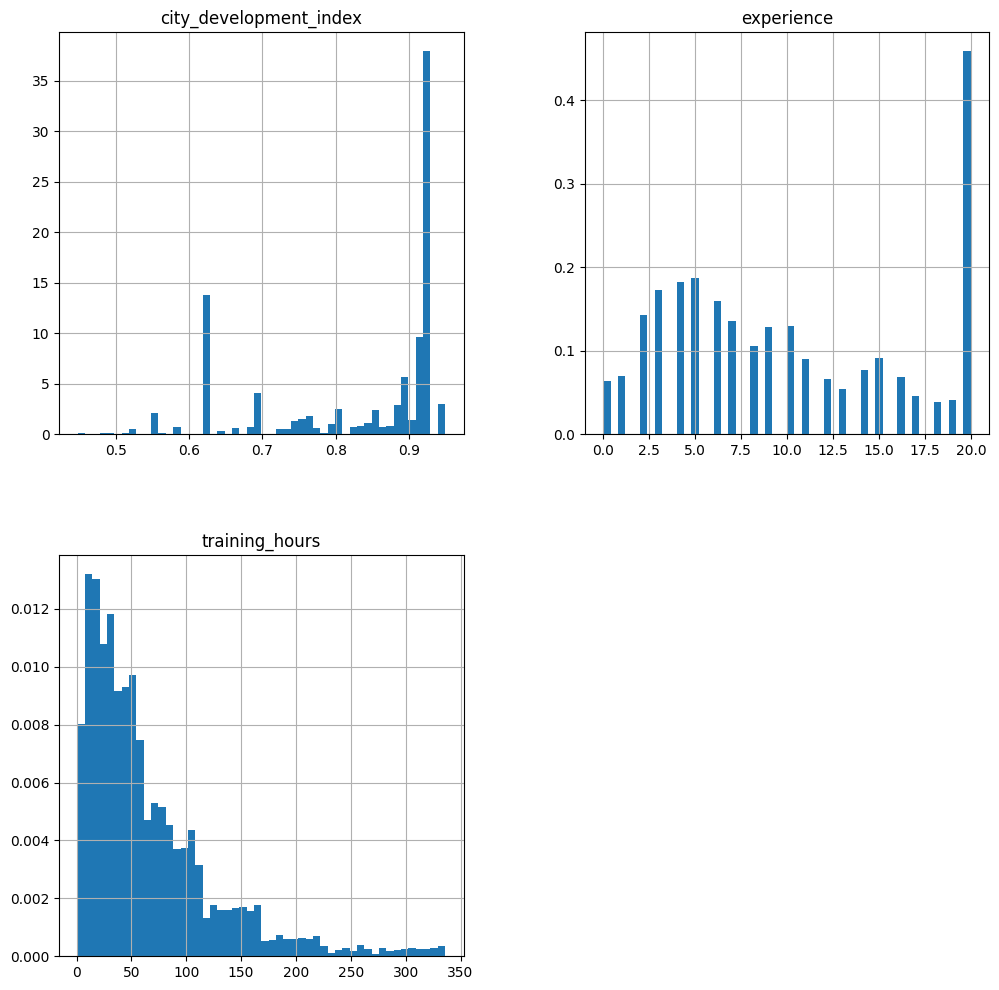

In [15]:
new_df.hist(bins=50,density=True, figsize=(12,12))
plt.show()

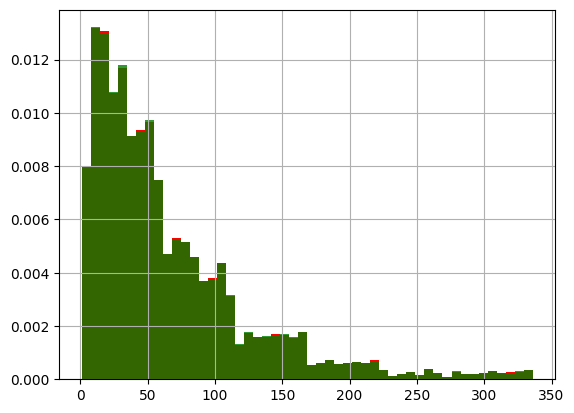

In [22]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['training_hours'].hist(bins=50,ax=ax,density=True,color='red') #original data

#data after cca,the argument alpha makes the distribution transparent,so we can see the overlap of 2 distribution
#alpha ranges b/w 0-1

new_df['training_hours'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8) #new data
plt.show()

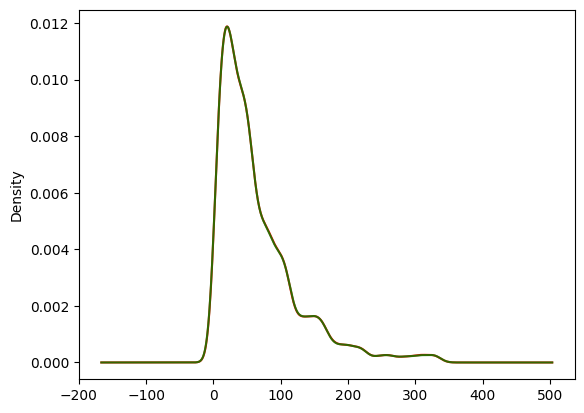

In [29]:
fig=plt.figure()

df['training_hours'].plot.density(color='red')
new_df['training_hours'].plot.density(color='green',alpha=0.8)
plt.show()

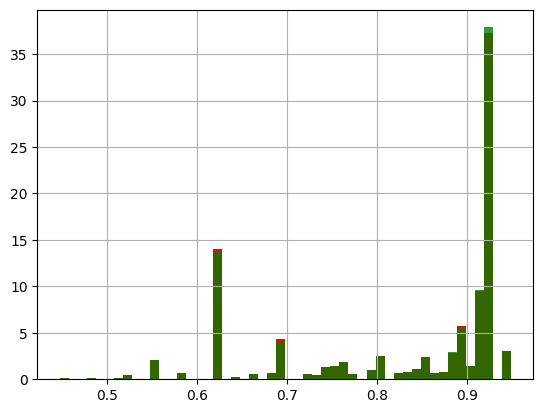

In [30]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['city_development_index'].hist(bins=50,ax=ax,density=True,color='red') #original data

#data after cca,the argument alpha makes the distribution transparent,so we can see the overlap of 2 distribution
#alpha ranges b/w 0-1

new_df['city_development_index'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8) #new data
plt.show()

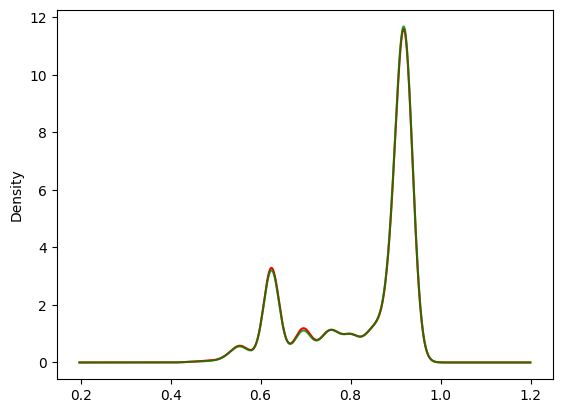

In [31]:
fig=plt.figure()

df['city_development_index'].plot.density(color='red')
new_df['city_development_index'].plot.density(color='green',alpha=0.8)
plt.show()

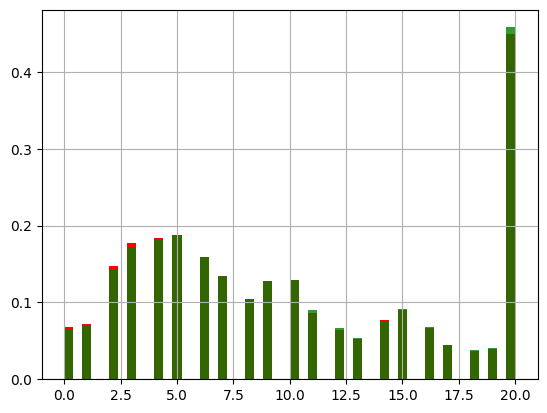

In [32]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['experience'].hist(bins=50,ax=ax,density=True,color='red') #original data

#data after cca,the argument alpha makes the distribution transparent,so we can see the overlap of 2 distribution
#alpha ranges b/w 0-1

new_df['experience'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8) #new data
plt.show()

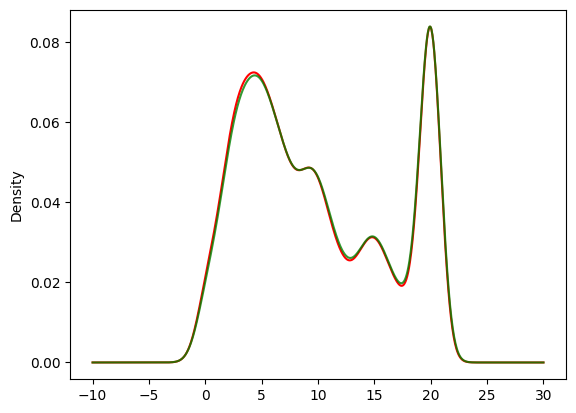

In [33]:
fig=plt.figure()

df['experience'].plot.density(color='red')
new_df['experience'].plot.density(color='green',alpha=0.8)
plt.show()

graph for categorical column

In [34]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
12947,NaN,no_enrollment,Graduate,5.0,75.0
287,0.698,no_enrollment,Graduate,8.0,23.0
5333,0.624,no_enrollment,Graduate,2.0,6.0
8420,0.624,no_enrollment,Graduate,3.0,69.0
13579,0.624,no_enrollment,Graduate,9.0,52.0


In [35]:
df['enrolled_university'].value_counts()

,count
enrolled_university,
no_enrollment,13817
Full time course,3757
Part time course,1198


In [36]:
df['education_level'].value_counts()

,count
education_level,
Graduate,11598
Masters,4361
High School,2017
Phd,414
Primary School,308


In [40]:
temp=pd.concat([
    # % of observation per category for original data
    df['education_level'].value_counts()/len(df)*100,
    # % of observation per category for caa data
    new_df['education_level'].value_counts()/len(df)*100,
],axis=1)

temp.columns=['original','ccs']
#not very big difference
temp

,original,ccs
education_level,,
Graduate,60.538678,55.590354
Masters,22.763336,20.993841
High School,10.528239,9.630442
Phd,2.160977,1.983506
Primary School,1.607683,1.487629


In [41]:
temp=pd.concat([
    # % of observation per category for original data
    df['enrolled_university'].value_counts()/len(df)*100,

    # % of observation per category for caa data
    new_df['enrolled_university'].value_counts()/len(df)*100,
],axis=1)

temp.columns=['original','ccs']
#not very big difference
temp

,original,ccs
enrolled_university,,
no_enrollment,72.121307,65.935901
Full time course,19.610607,18.002923
Part time course,6.253262,5.746946


In [ ]:
#not very big difference so we can perform caa in this given dataset
#this also conclude data is MCAR(missing completely at random)